# Testing pose estimation

In [1]:
import torch

print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.9.1+cu126 12.6 True
NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:
from pathlib import Path

import imageio.v3 as iio
from PIL import Image, ImageDraw
import numpy as np

from aitraf.processing import sample_frame_indices
from aitraf.utils import (
    get_video_rotation_deg,
    draw_bounding_boxes,
    draw_pose_keypoints,
    POSE_DEFAULT_SKELETON,
)


RAW_EXPORT_PATH = Path("../data/labels.jsonl")
CLIPS_DIR = Path("../data/clips")
YOLO_WEIGHTS = Path("../models/yolo11n-pose.pt")
BOXES_DIR = Path("../data/boxes")
POSES_DIR = Path("../data/poses")
SAMPLING_DIST = "uniform"


#### Load video

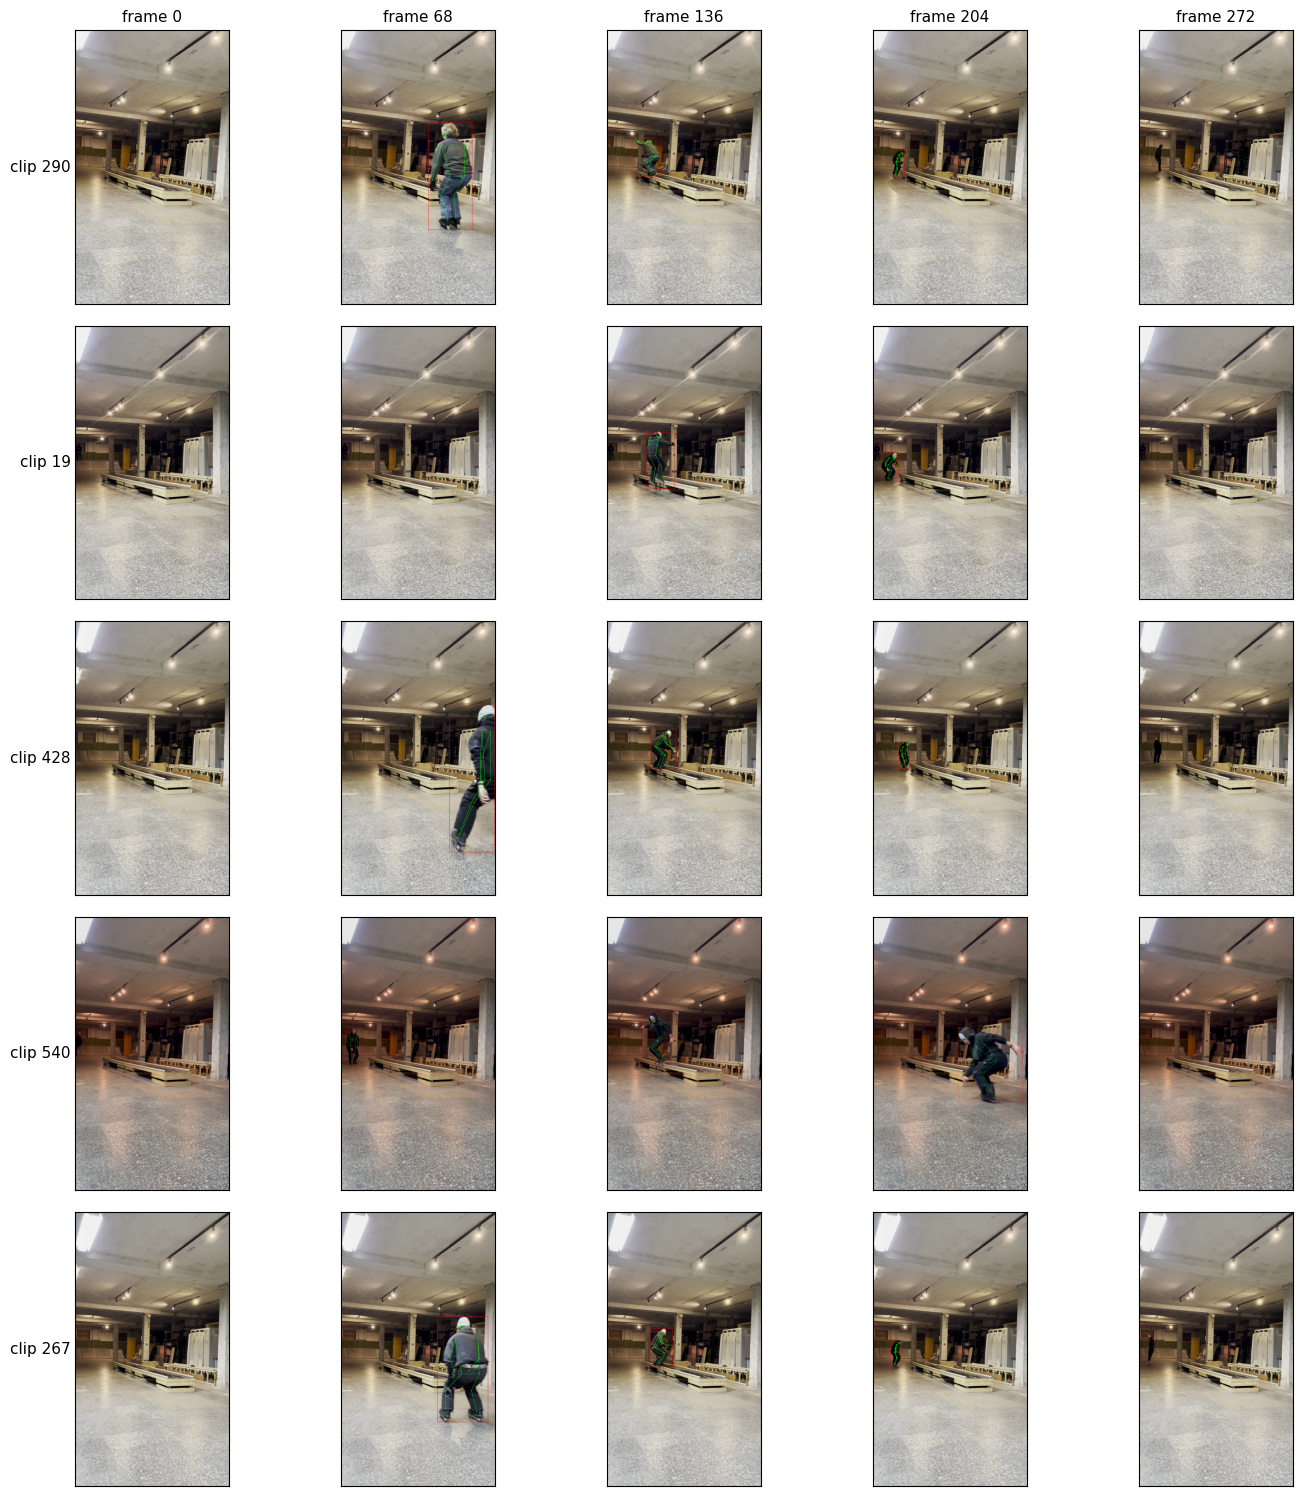

In [3]:
import matplotlib.pyplot as plt

NUM_CLIPS = 5
NUM_FRAMES = 5
RNG_SEED = 1

skeleton = POSE_DEFAULT_SKELETON


def sample_clip_indices(num_clips, clip_paths, rng):
    max_clips = min(num_clips, len(clip_paths))
    return rng.choice(len(clip_paths), size=max_clips, replace=False)


def load_clip_data(clip_path):
    rotation = get_video_rotation_deg(clip_path)
    k = (rotation // 90) % 4 if rotation else 0
    frames = [np.rot90(frame, k=k) if k else frame for frame in iio.imiter(clip_path)]

    box_path = BOXES_DIR / f"{clip_path.stem}.npz"
    pose_path = POSES_DIR / f"{clip_path.stem}.npz"
    boxes = np.load(box_path, allow_pickle=True)["boxes"]
    poses = np.load(pose_path, allow_pickle=True)["keypoints"]
    return frames, boxes, poses




rng = np.random.default_rng(RNG_SEED)
clip_paths = sorted([p for p in CLIPS_DIR.iterdir() if p.is_file()])
if not clip_paths:
    raise ValueError(f"No clips found in {CLIPS_DIR}")

clip_indices = sample_clip_indices(NUM_CLIPS, clip_paths, rng)
selected_clips = [clip_paths[i] for i in clip_indices]

fig, axes = plt.subplots(
    len(selected_clips),
    NUM_FRAMES,
    figsize=(NUM_FRAMES * 2.8, len(selected_clips) * 3.2),
)
axes = np.atleast_2d(axes)
fig.subplots_adjust(wspace=0.0, hspace=0.08, left=0.04, right=0.99, top=0.95, bottom=0.04)

for row, (clip_idx, clip_path) in enumerate(zip(clip_indices, selected_clips)):
    frames, boxes, poses = load_clip_data(clip_path)
    num_available = len(frames)
    num_to_sample = min(NUM_FRAMES, num_available)
    frame_indices = sample_frame_indices(
        total_frames=num_available,
        num_frames=num_to_sample,
        sampling_dist=SAMPLING_DIST,
        source=clip_path,
    )

    for col, frame_idx in enumerate(frame_indices):
        frame = frames[frame_idx]
        h, w = frame.shape[:2]
        img = Image.fromarray(frame.copy())
        draw = ImageDraw.Draw(img)

        draw_bounding_boxes(
            draw,
            boxes[frame_idx],
            width=w,
            height=h,
        )
        draw_pose_keypoints(
            draw,
            poses[frame_idx],
            width=w,
            height=h,
            skeleton=skeleton,
        )

        ax = axes[row, col]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"frame {frame_idx}", fontsize=11)
        if col == 0:
            ax.set_ylabel(f"clip {clip_idx}", rotation=0, ha="right", va="center", fontsize=11, labelpad=3)

plt.show()
